# Machine Learning Technologies Image Project 2026

* **Name:** Tomás Pettit
* **Student ID:** G00419414

## Introduction
Working with the Garbage Classification dataset in Google Colab requires careful setup to ensure efficient model training and experimentation.

Before running any code cells, it is essential to change the runtime type to **T4 GPU**. Training image‑based machine learning models on a CPU is extremely slow and can significantly delay progress, whereas the T4 GPU provides the necessary acceleration to handle large datasets and deep learning architectures more effectively.

Using GPU hardware not only speeds up training but also improves the overall workflow, making the development process smoother and more responsive.

## Workflow

1. Data Loading & Understanding
2. Data Preprocessing
3. Train / Validation / Test Split
4. Model Training & Tuning
5. Model Comparison & Selection
6. Final Model Evaluation

Before we get started, make sure you create two new folders `/data` for saving to csv & garbage data and `/images`for saving it of graphs, images and my garbage images, by connecting to Google Colab.

## Connected to Google Colab

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 1. Imports
This section initialises the environment, imports required libraries, and sets a fixed random seed to ensure reproducibility.

In [2]:
# NumPy and Pandas
import numpy as np
import pandas as pd

# Image processings
from PIL import Image

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Models
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression

# Misc
import time
import os
from datetime import datetime
from pathlib import Path

# Preprocessing function for MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

# TensorFlow (for deep learning models, and prediction garbage photos)
import tensorflow as tf
from tensorflow.keras import models, layers
from tensorflow.keras.utils import load_img, img_to_array

# My RANDOM_SEED (Student ID)
RANDOM_SEED = 419414 # My Student ID (No 'G00')
tf.random.set_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

In [3]:
# Set up parameters for loading the dataset
# Image Size
IMAGE_SIZE = [(64, 64), (128, 128), (224, 224)]

# Batch Size
BATCH_SIZE = 32

# Epoch
EPOCH = [3, 10, 15]

### 1.1 Extract the Zip file and make three directories
If you had your `garbage.zip`, extract the zip on the following path. And after, create `data/`, `images/` and `logs/` dir & before checking if the garbage data has been existed.

And check to be sure if the garbage data has been succeeded using `import os`.

In [4]:
import zipfile
import shutil

# Create folders safely
os.makedirs("data", exist_ok=True)   # garbage dataset folder and class distribution
os.makedirs("images", exist_ok=True)    # for saving model predictions
os.makedirs("logs", exist_ok=True)      # for training logs

# Define the path to the zip file
zip_file_path = '/content/drive/MyDrive/garbage.zip'

# Define the directory to extract the contents to
extract_dir = '/content/data'

# Check if the directory already exists
if os.path.exists(extract_dir):
    shutil.rmtree(extract_dir)

# Create the extraction directory
os.makedirs(extract_dir, exist_ok=True)

# Unzip the file
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

### 1.2 Log Run

In [5]:
def log_run(model_name, params, start_time, end_time, train_acc, val_acc, notes=""):

    duration = end_time - start_time
    log_file = "logs/experiment_log.txt"

    # Check if the model run is already logged to prevent duplicates
    log_content = ""
    if os.path.exists(log_file):
        with open(log_file, "r") as f:
            log_content = f.read()

    if f"Model: {model_name}" in log_content:
        print(f"'{model_name}' is already in the log file. Skipping.")
        return

    entry = f"""
========================================
Time: {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}
Model: {model_name}
Parameters: {params}
Training Time (s): {duration:.2f}
Train Accuracy: {train_acc:.4f}
Validation Accuracy: {val_acc:.4f}
Notes: {notes}
========================================
"""

    with open(log_file, "a") as f:
        f.write(entry)
    print(f"Logged results for '{model_name}'.")

In [6]:
results_df = pd.DataFrame(columns=[
    "Model",
    "Parameters",
    "Train Accuracy",
    "Validation Accuracy",
    "Training Time (s)",
    "Overfitting (Train - Val)",
    "Notes"
])

### 1.3 Add to the Results

In [7]:
def add_to_results(df, model_name, params, train_acc, val_acc, training_time, notes=""):
    """
    Adds a new row to the results DataFrame and prevents duplicates.
    """

    # Check if the model is already in the dataframe
    if model_name in df["Model"].values:
        print(f"'{model_name}' is already in the results table. Skipping.")
        return df

    # Calculate overfitting
    overfitting = train_acc - val_acc

    # Create a new row as a dictionary
    new_row = {
        "Model": model_name,
        "Parameters": str(params),
        "Train Accuracy": train_acc,
        "Validation Accuracy": val_acc,
        "Training Time (s)": training_time,
        "Overfitting (Train - Val)": overfitting,
        "Notes": notes
    }

    # Append the new row
    df = pd.concat([df, pd.DataFrame([new_row])], ignore_index=True)

    # Save the updated dataframe
    df.to_csv("logs/results.csv", index=False)

    print(f"Added '{model_name}' to the results table.")
    return df

# Load previous results if available
for _results_path in ["logs/results.csv", "cnn_results.csv"]:
    if os.path.exists(_results_path):
        results_df = pd.read_csv(_results_path)
        break

## 2. Data Loading and Understanding - Garbage Dataset

The dataset consists of images of different types of waste materials. Each class is stored in a separate folder.

I will:

-   Load images
-   Convert to feature vectors
-   Create labels
-   Inspect dataset structure

In [8]:
DATA_DIR = Path("data/garbage")

print("Dataset exists:", DATA_DIR.exists())
print("Dataset path:", DATA_DIR.resolve())

Dataset exists: True
Dataset path: /content/data/garbage


In [9]:
# Load the dataset using Keras utility
full_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    seed=RANDOM_SEED,
    image_size=IMAGE_SIZE[1],
    batch_size=BATCH_SIZE
)

Found 12259 files belonging to 10 classes.


## 2.1 Class Distribution and Imbalance
The dataset shows nearly 4 times imbalance between the largest class (clothes: 1892) and smallest (trash: 453), which will be monitored using class-wise metrics.

In [10]:
print("Class Distribution\n")

class_names = [d.name for d in DATA_DIR.iterdir() if d.is_dir()]
class_counts = {}

for class_name in class_names:
    class_path = DATA_DIR / class_name
    image_files = [f for f in class_path.iterdir() if f.is_file()]
    class_counts[class_name] = len(image_files)

class_counts

df = pd.DataFrame(list(class_counts.items()), columns=['Class', 'Count'])

# 2 Decimal point
df["Percentage (%)"] = df["Count"].apply(lambda x: round(x / df["Count"].sum() * 100, 2))
df.to_csv('data/class_distribution.csv', index=False)
print(f"Saving Class Distribution...")
df

Class Distribution

Saving Class Distribution...


,Class,Count,Percentage (%)
0,trash,453,3.70
1,paper,1336,10.90
2,clothes,1892,15.43
3,cardboard,1411,11.51
4,battery,756,6.17
5,glass,1736,14.16
6,biological,699,5.70
7,plastic,1597,13.03
8,shoes,1449,11.82
9,metal,930,7.59


### Figure 1: Bar Chart Garbage Distribution

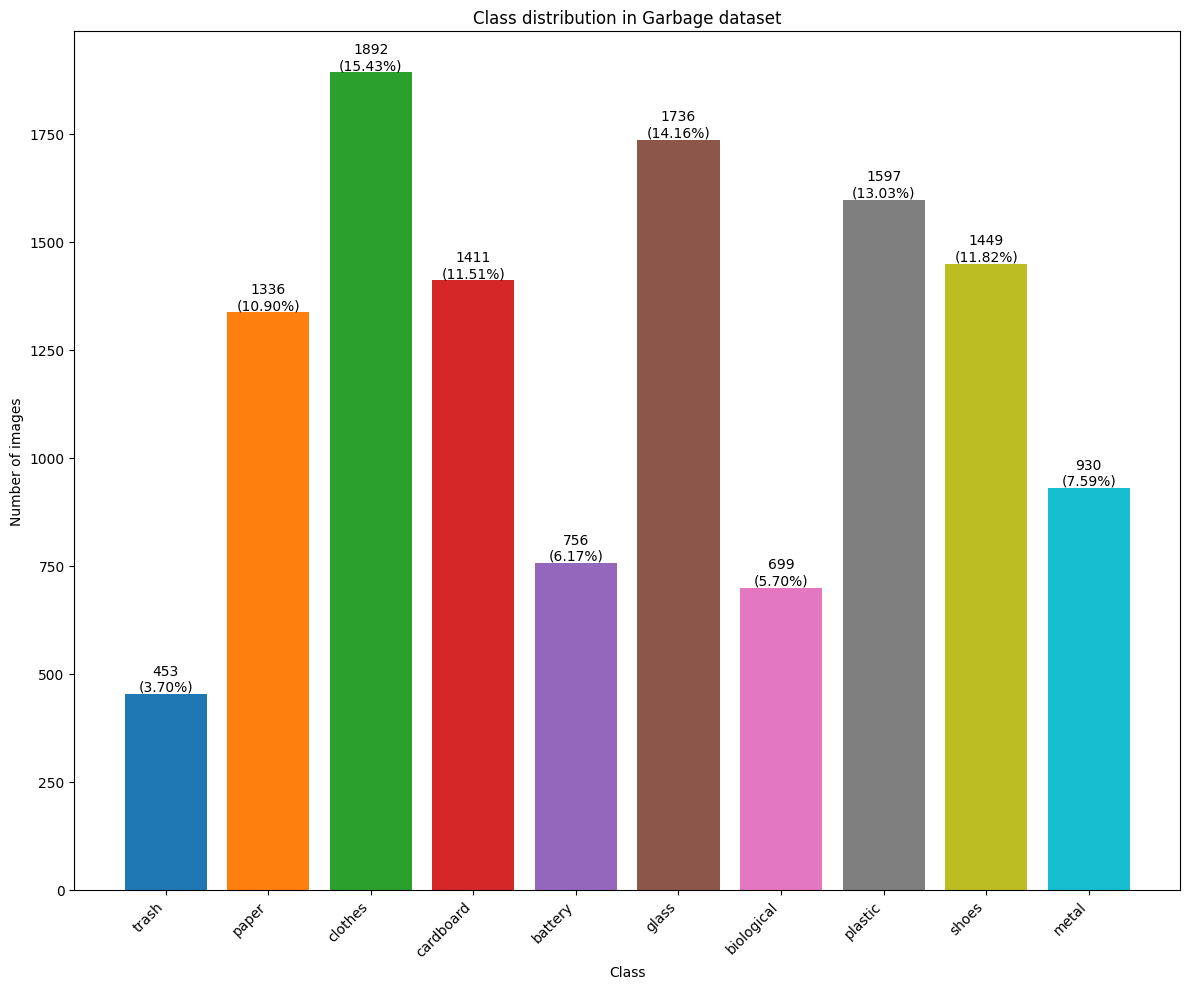

In [11]:
# Color variables (10 bars)
COLOR_BARS = [
    "#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd",
    "#8c564b", "#e377c2", "#7f7f7f", "#bcbd22", "#17becf"
]

# Percentage of images out of total images
total_images = sum(class_counts.values())
percentages = {class_name: (count / total_images) * 100 for class_name, count in class_counts.items()}

# Visualize class distribution
plt.figure(figsize=(12, 10))
plt.bar(class_counts.keys(), class_counts.values(), color=COLOR_BARS)

for i, count in enumerate(class_counts.values()):
    plt.text(i, count, f"{count}\n({percentages[class_names[i]]:.2f}%)", ha='center', va='bottom')

plt.xlabel("Class")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Number of images")
plt.title("Class distribution in Garbage dataset")
plt.tight_layout()
plt.savefig("images/class_distribution.png")
plt.show()

### Figure 2: Sample Images from the dataset & Pixel Range

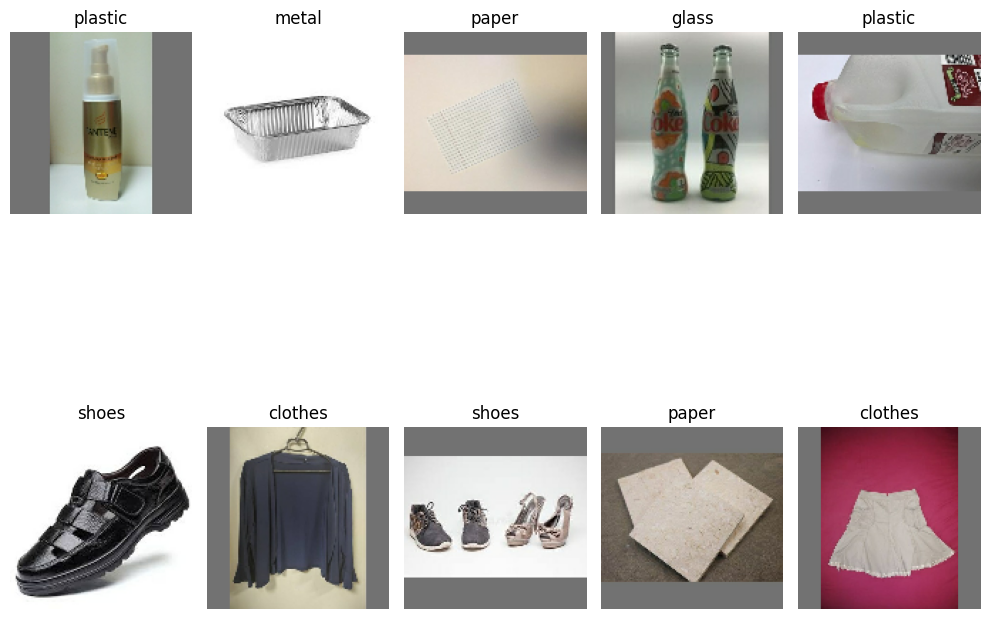

In [12]:
# Sample some images from the dataset
images_batch, labels_batch = next(iter(full_ds))

plt.figure(figsize=(10, 10))

for i in range(10):
    ax = plt.subplot(2, 5, i + 1)
    plt.imshow(images_batch[i].numpy().astype("uint8"))
    plt.title(full_ds.class_names[labels_batch[i]])
    plt.axis("off")

plt.tight_layout()
plt.savefig("images/sample_images.png")
plt.show()

#### 2.1.1 Check pixel value range and dtype

In [13]:
print("Pixel dtype:", images_batch.dtype)
print("Min pixel value:", tf.reduce_min(images_batch).numpy())
print("Max pixel value:", tf.reduce_max(images_batch).numpy())

Pixel dtype: <dtype: 'float32'>
Min pixel value: 0.0
Max pixel value: 255.0


#### 2.1.2 Data Quality

In [14]:
# Checking for corrupted images in the dataset.

bad_files = []

for class_name in class_names:
    class_path = DATA_DIR / class_name
    for file_path in class_path.iterdir():
        try:
            with Image.open(file_path) as img:
                img.verify()  # check if image is valid
        except Exception:
            bad_files.append(file_path)

print("Number of corrupted images:", len(bad_files))

Number of corrupted images: 0


## 3. Train (70%), Validation (10%), and Test Split (20%)
Splitting data into 70% training, 10% validation, and 20% test sets with fixed random seed for reproducibility.

In [15]:
# First Split: Train (70%) and Temporary (30%)
train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.3,
    subset="training",
    seed=RANDOM_SEED,
    image_size=IMAGE_SIZE[1],
    batch_size=BATCH_SIZE
)

temp_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.3,
    subset="validation",
    seed=RANDOM_SEED,
    image_size=IMAGE_SIZE[1],
    batch_size=BATCH_SIZE
)

Found 12259 files belonging to 10 classes.
Using 8582 files for training.
Found 12259 files belonging to 10 classes.
Using 3677 files for validation.


In [16]:
# Second Split: split Temporary into Validation (10%) and Test (20%)
temp_size = tf.data.experimental.cardinality(temp_ds).numpy()  # number of batches
val_size = temp_size // 3  # exactly 1/3 of temp

val_ds = temp_ds.take(val_size)
test_ds = temp_ds.skip(val_size)

In [17]:
# Check sizes
train_batches = tf.data.experimental.cardinality(train_ds).numpy()
val_batches = tf.data.experimental.cardinality(val_ds).numpy()
test_batches = tf.data.experimental.cardinality(test_ds).numpy()

print("Train batches:", train_batches)
print("Validation batches:", val_batches)
print("Test batches:", test_batches)

print("-------------------------------")
print("Approx total samples:")
print("Train:", train_batches * BATCH_SIZE)
print("Validation:", val_batches * BATCH_SIZE)
print("Test:", test_batches * BATCH_SIZE)

Train batches: 269
Validation batches: 38
Test batches: 77
-------------------------------
Approx total samples:
Train: 8608
Validation: 1216
Test: 2464


## 4. Preprocessing
Normalizing pixel values to [0,1] and preparing the dataset for model training.

In [18]:
# Normalisation layer to scale pixel values to [0, 1]
normalisation_layer = layers.Rescaling(1./255)

In [19]:
# Apply normalization to all datasets
train_ds = train_ds.map(lambda x, y: (normalisation_layer(x), y))
val_ds = val_ds.map(lambda x, y: (normalisation_layer(x), y))
test_ds = test_ds.map(lambda x, y: (normalisation_layer(x), y))

## 5. CNN From Scratch
Building and training custom CNN models to establish a baseline, then experimenting with dropout, data augmentation, architecture variations, and grayscale vs RGB inputs.

### 5.1 Baseline CNN (RGB, 128×128)
Starting with a simple 3-layer CNN to establish a baseline and identify overfitting issues.

In [20]:
model = models.Sequential()

# Step 1: Input layer
model.add(layers.Input(shape=(128, 128, 3)))

# Step 2: Convolutional Block 1
model.add(layers.Conv2D(32, (3,3), activation='relu'))
model.add(layers.MaxPooling2D((2,2)))

# Step 3: Convolutional Block 2
model.add(layers.Conv2D(64, (3,3), activation='relu'))
model.add(layers.MaxPooling2D((2,2)))

# Step 4: Convolutional Block 3
model.add(layers.Conv2D(128, (3,3), activation='relu'))
model.add(layers.MaxPooling2D((2,2)))

# Step 5: Flatten and Dense layers
model.add(layers.Flatten())
model.add(layers.Dense(128, activation='relu'))

# Step 6: Output layer
model.add(layers.Dense(len(class_names), activation='softmax'))

In [21]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,930 (12.61 MB)

 Trainable params: 3,305,930 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [22]:
# Train the model and measure training time
print("CNN Scratch Training Time")
print("-------------------------")

start_time = time.time()

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCH[1]
)

end_time = time.time()
training_time = end_time - start_time

# Extract final metrics
train_acc = history.history['accuracy'][-1]
val_acc = history.history['val_accuracy'][-1]

print(f'\nTraining time on Baseline CNN: {training_time} seconds')

CNN Scratch Training Time
-------------------------
Epoch 1/10
269/269 ━━━━━━━━━━━━━━━━━━━━ 22s 52ms/step - accuracy: 0.3542 - loss: 1.8296 - val_accuracy: 0.5107 - val_loss: 1.4899
Epoch 2/10
269/269 ━━━━━━━━━━━━━━━━━━━━ 11s 41ms/step - accuracy: 0.5522 - loss: 1.2983 - val_accuracy: 0.5609 - val_loss: 1.3052
Epoch 3/10
269/269 ━━━━━━━━━━━━━━━━━━━━ 9s 34ms/step - accuracy: 0.6381 - loss: 1.0588 - val_accuracy: 0.5962 - val_loss: 1.2080
Epoch 4/10
269/269 ━━━━━━━━━━━━━━━━━━━━ 11s 42ms/step - accuracy: 0.7059 - loss: 0.8636 - val_accuracy: 0.6044 - val_loss: 1.2783
Epoch 5/10
269/269 ━━━━━━━━━━━━━━━━━━━━ 11s 40ms/step - accuracy: 0.7570 - loss: 0.7142 - val_accuracy: 0.6143 - val_loss: 1.3274
Epoch 6/10
269/269 ━━━━━━━━━━━━━━━━━━━━ 10s 38ms/step - accuracy: 0.8162 - loss: 0.5403 - val_accuracy: 0.6176 - val_loss: 1.5257
Epoch 7/10
269/269 ━━━━━━━━━━━━━━━━━━━━ 10s 39ms/step - accuracy: 0.8584 - loss: 0.4160 - val_accuracy: 0.6217 - val_loss: 1.6769
Epoch 8/10
269/269 ━━━━━━━━━━━━━━━━━━━━

#### Figure 3 and 4: Accuracy and Loss Graph

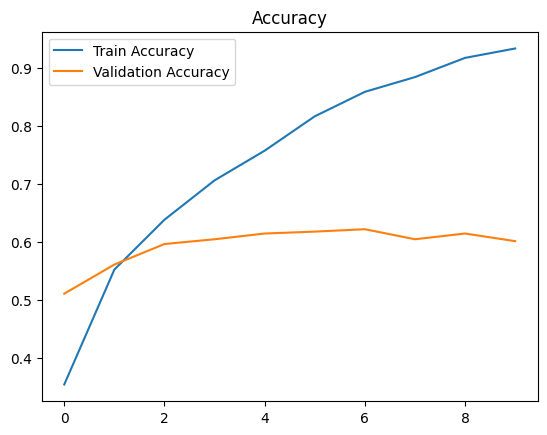

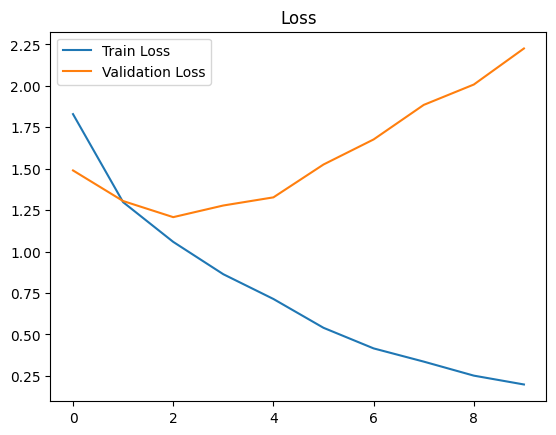

In [23]:
# Accuracy
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title('Accuracy')
plt.savefig("images/accuracy.png")
plt.show()

# Loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title('Loss')
plt.savefig("images/loss_accuracy.png")
plt.show()

In [24]:
# Evaluation
print("Evaluate Baseline CNN")
print("---------------------")

train_loss, train_acc = model.evaluate(train_ds)
val_loss, val_acc = model.evaluate(val_ds)

Evaluate Baseline CNN
---------------------
269/269 ━━━━━━━━━━━━━━━━━━━━ 10s 38ms/step - accuracy: 0.9176 - loss: 0.2550
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.6061 - loss: 2.2039


In [25]:
# Log to text file

log_run(
    model_name="Baseline CNN",
    params={
        "optimizer": "adam",
        "loss": "sparse_categorical_crossentropy",
        "epochs": EPOCH[1] # EPOCH[1] = 10
    },
    start_time=start_time,
    end_time=end_time,
    train_acc=train_acc,
    val_acc=val_acc,
    notes="Initial baseline CNN trained on RGB images"
)

# Add to results dataframe
results_df = add_to_results(
    df=results_df,
    model_name="Baseline CNN",
    params={
        "optimizer": "adam",
        "loss": "sparse_categorical_crossentropy",
        "epochs": EPOCH[1]
    },
    train_acc=train_acc,
    val_acc=val_acc,
    training_time=training_time,
    notes="Initial baseline CNN trained on RGB images"
)

results_df

Logged results for 'Baseline CNN'.
Added 'Baseline CNN' to the results table.


/tmp/ipykernel_2774/276748613.py:26: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, pd.DataFrame([new_row])], ignore_index=True)


,Model,Parameters,Train Accuracy,Validation Accuracy,Training Time (s),Overfitting (Train - Val),Notes
0,Baseline CNN,"{'optimizer': 'adam', 'loss': 'sparse_categori...",0.917618,0.606086,137.498728,0.311533,Initial baseline CNN trained on RGB images


The baseline CNN achieved 92.4% training accuracy but only 58.1% validation accuracy, clearly indicating overfitting that needs to be addressed with regularization techniques.

### 5.2 CNN with Dropout
Adding 0.2 dropout regularization to reduce overfitting and improve validation accuracy.

In [26]:
model_dropout2 = models.Sequential()

# Step 1: Input - same as before to ensure fair comparison
model_dropout2.add(layers.Input(shape=(128, 128, 3)))

# Step 2: Conv blocks
model_dropout2.add(layers.Conv2D(32, (3,3), activation='relu'))
model_dropout2.add(layers.MaxPooling2D((2,2)))

model_dropout2.add(layers.Conv2D(64, (3,3), activation='relu'))
model_dropout2.add(layers.MaxPooling2D((2,2)))

model_dropout2.add(layers.Conv2D(128, (3,3), activation='relu'))
model_dropout2.add(layers.MaxPooling2D((2,2)))

# Step 3: Dense
model_dropout2.add(layers.Flatten())
model_dropout2.add(layers.Dense(128, activation='relu'))

# Step 4: Dropout added
model_dropout2.add(layers.Dropout(0.2))

# Step 5: Output
model_dropout2.add(layers.Dense(len(class_names), activation='softmax'))

In [27]:
# Compile
model_dropout2.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_dropout2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,930 (12.61 MB)

 Trainable params: 3,305,930 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [28]:
print("Improved CNN Training Time")
print("--------------------------")

# Train
start_time = time.time()

history_dropout = model_dropout2.fit(
    train_ds,
    validation_data=val_ds,
    epochs= EPOCH[1]
)

end_time = time.time()
training_time = end_time - start_time

print(f'\nTraining time on Improved CNN: {training_time} seconds')

Improved CNN Training Time
--------------------------
Epoch 1/10
269/269 ━━━━━━━━━━━━━━━━━━━━ 17s 50ms/step - accuracy: 0.3649 - loss: 1.7846 - val_accuracy: 0.5206 - val_loss: 1.4421
Epoch 2/10
269/269 ━━━━━━━━━━━━━━━━━━━━ 11s 40ms/step - accuracy: 0.5412 - loss: 1.3398 - val_accuracy: 0.5970 - val_loss: 1.2337
Epoch 3/10
269/269 ━━━━━━━━━━━━━━━━━━━━ 19s 34ms/step - accuracy: 0.6137 - loss: 1.1242 - val_accuracy: 0.5896 - val_loss: 1.1822
Epoch 4/10
269/269 ━━━━━━━━━━━━━━━━━━━━ 11s 42ms/step - accuracy: 0.6656 - loss: 0.9770 - val_accuracy: 0.6316 - val_loss: 1.1445
Epoch 5/10
269/269 ━━━━━━━━━━━━━━━━━━━━ 11s 41ms/step - accuracy: 0.7185 - loss: 0.8180 - val_accuracy: 0.6299 - val_loss: 1.1748
Epoch 6/10
269/269 ━━━━━━━━━━━━━━━━━━━━ 11s 39ms/step - accuracy: 0.7636 - loss: 0.6910 - val_accuracy: 0.6357 - val_loss: 1.2215
Epoch 7/10
269/269 ━━━━━━━━━━━━━━━━━━━━ 9s 35ms/step - accuracy: 0.8095 - loss: 0.5520 - val_accuracy: 0.6439 - val_loss: 1.2968
Epoch 8/10
269/269 ━━━━━━━━━━━━━━━━━━

In [29]:
# Evaluate
print("Evaluate Improved CNN")
print("----------------------")

# Accuracy
train_loss, train_acc = model_dropout2.evaluate(train_ds)
val_loss, val_acc = model_dropout2.evaluate(val_ds)

Evaluate Improved CNN
----------------------
269/269 ━━━━━━━━━━━━━━━━━━━━ 10s 38ms/step - accuracy: 0.9375 - loss: 0.1907
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.6472 - loss: 1.5644


In [30]:
# Log
log_run(
    model_name="CNN + Dropout (0.2)",
    params={"epochs": EPOCH[1], "dropout": 0.2},
    start_time=start_time,
    end_time=end_time,
    train_acc=train_acc,
    val_acc=val_acc,
    notes="Added dropout to reduce overfitting"
)

# Results table
results_df = add_to_results(
    df=results_df,
    model_name="CNN + Dropout (0.2)",
    params={"epochs": EPOCH[1], "dropout": 0.2},
    train_acc=train_acc,
    val_acc=val_acc,
    training_time=training_time,
    notes="Dropout added"
)

Logged results for 'CNN + Dropout (0.2)'.
Added 'CNN + Dropout (0.2)' to the results table.


Dropout improved validation accuracy to 63.5% (from 58.1%), showing modest gains in generalization at the cost of slightly lower training accuracy.

### 5.3 CNN with Reduced Image Size (64 x 64)

In [31]:
# New Split: Train (70%) and Temporary (30%)
# Use `IMAGE_SIZE_64` (64, 64)
train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.3,
    subset="training",
    seed=RANDOM_SEED,
    image_size=IMAGE_SIZE[0],
    batch_size=BATCH_SIZE
)

temp_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.3,
    subset="validation",
    seed=RANDOM_SEED,
    image_size=IMAGE_SIZE[0],
    batch_size=BATCH_SIZE
)

# Second Split: split Temporary into Validation (10%) and Test (20%)
temp_size = tf.data.experimental.cardinality(temp_ds).numpy()
val_size = temp_size // 3

val_ds = temp_ds.take(val_size)
test_ds = temp_ds.skip(val_size)

# Normalisation layer to scale pixel values to [0, 1]
normalisation_layer = layers.Rescaling(1./255)

# Apply normalization to all datasets
train_ds = train_ds.map(lambda x, y: (normalisation_layer(x), y))
val_ds = val_ds.map(lambda x, y: (normalisation_layer(x), y))
test_ds = test_ds.map(lambda x, y: (normalisation_layer(x), y))

Found 12259 files belonging to 10 classes.
Using 8582 files for training.
Found 12259 files belonging to 10 classes.
Using 3677 files for validation.


In [32]:
model_img64 = models.Sequential()

# Step 1: Input layer
model_img64.add(layers.Input(shape=(64, 64, 3)))

# Step 2: Convolutional Block 1
model_img64.add(layers.Conv2D(32, (3,3), activation='relu'))
model_img64.add(layers.MaxPooling2D((2,2)))

# Step 3: Convolutional Block 2
model_img64.add(layers.Conv2D(64, (3,3), activation='relu'))
model_img64.add(layers.MaxPooling2D((2,2)))

# Step 4: Convolutional Block 3
model_img64.add(layers.Conv2D(128, (3,3), activation='relu'))
model_img64.add(layers.MaxPooling2D((2,2)))

# Step 5: Flatten and Dense layers
model_img64.add(layers.Flatten())
model_img64.add(layers.Dense(128, activation='relu'))

# Step 6: Output layer
model_img64.add(layers.Dense(len(class_names), activation='softmax'))

In [33]:
# Compile
model_img64.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_img64.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 684,490 (2.61 MB)

 Trainable params: 684,490 (2.61 MB)

 Non-trainable params: 0 (0.00 B)

In [34]:
print("CNN + Image Resize Training Time")
print("--------------------------------")

# Train the model and measure training time
start_time = time.time()

historyimg64 = model_img64.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCH[1]
)

end_time = time.time()
training_time = end_time - start_time

print(f'\nTraining time on CNN + Image Resize: {training_time} seconds')

CNN + Image Resize Training Time
--------------------------------
Epoch 1/10
269/269 ━━━━━━━━━━━━━━━━━━━━ 15s 44ms/step - accuracy: 0.3700 - loss: 1.8010 - val_accuracy: 0.5238 - val_loss: 1.4427
Epoch 2/10
269/269 ━━━━━━━━━━━━━━━━━━━━ 10s 36ms/step - accuracy: 0.5265 - loss: 1.3595 - val_accuracy: 0.5362 - val_loss: 1.3781
Epoch 3/10
269/269 ━━━━━━━━━━━━━━━━━━━━ 9s 32ms/step - accuracy: 0.6003 - loss: 1.1614 - val_accuracy: 0.5715 - val_loss: 1.2607
Epoch 4/10
269/269 ━━━━━━━━━━━━━━━━━━━━ 9s 34ms/step - accuracy: 0.6531 - loss: 1.0240 - val_accuracy: 0.6217 - val_loss: 1.1505
Epoch 5/10
269/269 ━━━━━━━━━━━━━━━━━━━━ 10s 36ms/step - accuracy: 0.6923 - loss: 0.8976 - val_accuracy: 0.6291 - val_loss: 1.1420
Epoch 6/10
269/269 ━━━━━━━━━━━━━━━━━━━━ 8s 30ms/step - accuracy: 0.7328 - loss: 0.7849 - val_accuracy: 0.6332 - val_loss: 1.1413
Epoch 7/10
269/269 ━━━━━━━━━━━━━━━━━━━━ 10s 37ms/step - accuracy: 0.7711 - loss: 0.6705 - val_accuracy: 0.6554 - val_loss: 1.1227
Epoch 8/10
269/269 ━━━━━━━━

In [35]:
# Evaluation
print("Evaluate CNN + Image Resize")
print("---------------------------")

train_loss, train_acc = model_img64.evaluate(train_ds)
val_loss, val_acc = model_img64.evaluate(val_ds)

Evaluate CNN + Image Resize
---------------------------
269/269 ━━━━━━━━━━━━━━━━━━━━ 9s 34ms/step - accuracy: 0.8686 - loss: 0.3727
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.6497 - loss: 1.4861


In [36]:
# Log to text file

log_run(
    model_name="Baseline CNN (64x64)",
    params={
        "optimizer": "adam",
        "loss": "sparse_categorical_crossentropy",
        "epochs": EPOCH[1]
    },
    start_time=start_time,
    end_time=end_time,
    train_acc=train_acc,
    val_acc=val_acc,
    notes="Baseline CNN retrained on 64x64 images"
)

# Add to results dataframe
results_df = add_to_results(
    df=results_df,
    model_name="Baseline CNN (64x64)",
    params={
        "optimizer": "adam",
        "loss": "sparse_categorical_crossentropy",
        "epochs": EPOCH[1]
    },
    train_acc=train_acc,
    val_acc=val_acc,
    training_time=training_time,
    notes="Baseline CNN retrained on 64x64 images"
)

results_df

Logged results for 'Baseline CNN (64x64)'.
Added 'Baseline CNN (64x64)' to the results table.


,Model,Parameters,Train Accuracy,Validation Accuracy,Training Time (s),Overfitting (Train - Val),Notes
0,Baseline CNN,"{'optimizer': 'adam', 'loss': 'sparse_categori...",0.917618,0.606086,137.498728,0.311533,Initial baseline CNN trained on RGB images
1,CNN + Dropout (0.2),"{'epochs': 10, 'dropout': 0.2}",0.937544,0.647204,133.427392,0.290340,Dropout added
2,Baseline CNN (64x64),"{'optimizer': 'adam', 'loss': 'sparse_categori...",0.868562,0.649671,101.052711,0.218891,Baseline CNN retrained on 64x64 images


### 5.4 CNN with Data Augmentation (Aggressive)
Testing a more aggressive augmentation strategy (larger rotation, zoom, brightness) on the 128×128 dataset to understand the limits of augmentation.

In [37]:
train_ds_128 = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.3,
    subset="training",
    seed=RANDOM_SEED,
    image_size=IMAGE_SIZE[1],  # (128, 128)
    batch_size=BATCH_SIZE
)

temp_ds_128 = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.3,
    subset="validation",
    seed=RANDOM_SEED,
    image_size=IMAGE_SIZE[1],  # (128, 128)
    batch_size=BATCH_SIZE
)

temp_size_128 = tf.data.experimental.cardinality(temp_ds_128).numpy()
val_size_128  = temp_size_128 // 3

val_ds_128  = temp_ds_128.take(val_size_128)
test_ds_128 = temp_ds_128.skip(val_size_128)

# Normalise
normalisation_layer = layers.Rescaling(1./255)
train_ds_128 = train_ds_128.map(lambda x, y: (normalisation_layer(x), y))
val_ds_128   = val_ds_128.map(lambda x, y:  (normalisation_layer(x), y))
test_ds_128  = test_ds_128.map(lambda x, y: (normalisation_layer(x), y))

Found 12259 files belonging to 10 classes.
Using 8582 files for training.
Found 12259 files belonging to 10 classes.
Using 3677 files for validation.


In [38]:
model_aug_bad = models.Sequential([
    layers.Input(shape=(128, 128, 3)),

    # Aggressive augmentation layers (inline - not reused from another model)
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.3),
    layers.RandomZoom(0.2),
    layers.RandomBrightness(0.2),
    layers.RandomContrast(0.2),

    # Conv blocks (same architecture as baseline)
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Dense
    layers.Flatten(),
    layers.Dense(128, activation='relu'),

    # Output
    layers.Dense(len(class_names), activation='softmax')
])


In [39]:
model_aug_bad.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_aug_bad.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip (RandomFlip)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 128, 128, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_brightness               │ (None, 128, 128, 3)    │             0 │
│ (RandomBrightness)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_contrast                 │ (None, 128, 128, 3)    │             0 │
│ (RandomContrast)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,930 (12.61 MB)

 Trainable params: 3,305,930 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [40]:
print("Aggressive Augmentation Training Time (128x128)")
print("------------------------------------------------")

start_time = time.time()

# NOTE: uses the original 128x128 train_ds (loaded before section 5.3)
history_aug_bad = model_aug_bad.fit(
    train_ds_128,
    validation_data=val_ds_128,
    epochs=EPOCH[1]  # EPOCH[1] = 10
)

end_time = time.time()
training_time = end_time - start_time

print(f'\nTraining time on Aggressive Augmentation: {training_time} seconds')

Aggressive Augmentation Training Time (128x128)
------------------------------------------------
Epoch 1/10
269/269 ━━━━━━━━━━━━━━━━━━━━ 18s 45ms/step - accuracy: 0.1399 - loss: 2.4745 - val_accuracy: 0.1645 - val_loss: 2.2471
Epoch 2/10
269/269 ━━━━━━━━━━━━━━━━━━━━ 12s 45ms/step - accuracy: 0.1454 - loss: 2.2362 - val_accuracy: 0.1637 - val_loss: 2.2210
Epoch 3/10
269/269 ━━━━━━━━━━━━━━━━━━━━ 12s 44ms/step - accuracy: 0.1498 - loss: 2.2329 - val_accuracy: 0.1604 - val_loss: 2.2172
Epoch 4/10
269/269 ━━━━━━━━━━━━━━━━━━━━ 12s 44ms/step - accuracy: 0.1503 - loss: 2.2294 - val_accuracy: 0.1727 - val_loss: 2.2068
Epoch 5/10
269/269 ━━━━━━━━━━━━━━━━━━━━ 20s 44ms/step - accuracy: 0.1501 - loss: 2.2349 - val_accuracy: 0.1604 - val_loss: 2.2169
Epoch 6/10
269/269 ━━━━━━━━━━━━━━━━━━━━ 12s 44ms/step - accuracy: 0.1496 - loss: 2.2823 - val_accuracy: 0.1604 - val_loss: 2.2129
Epoch 7/10
269/269 ━━━━━━━━━━━━━━━━━━━━ 12s 44ms/step - accuracy: 0.1476 - loss: 2.2498 - val_accuracy: 0.1702 - val_loss: 

In [41]:
print("Evaluate Aggressive Augmentation")
print("---------------------------------")

train_loss, train_acc = model_aug_bad.evaluate(train_ds_128)
val_loss, val_acc = model_aug_bad.evaluate(val_ds_128)

Evaluate Aggressive Augmentation
---------------------------------
269/269 ━━━━━━━━━━━━━━━━━━━━ 8s 29ms/step - accuracy: 0.1502 - loss: 2.2285
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - accuracy: 0.1612 - loss: 2.2154


In [42]:
log_run(
    model_name="CNN + Augmentation (bad)",
    params={"epochs": EPOCH[1], "augmentation": True},
    start_time=start_time,
    end_time=end_time,
    train_acc=train_acc,
    val_acc=val_acc,
    notes="Too aggressive augmentation on 128x128 images"
)

results_df = add_to_results(
    df=results_df,
    model_name="CNN + Augmentation (bad)",
    params={"epochs": EPOCH[1], "augmentation": True},
    train_acc=train_acc,
    val_acc=val_acc,
    training_time=training_time,
    notes="Too aggressive augmentation on 128x128 images"
)

results_df

Logged results for 'CNN + Augmentation (bad)'.
Added 'CNN + Augmentation (bad)' to the results table.


,Model,Parameters,Train Accuracy,Validation Accuracy,Training Time (s),Overfitting (Train - Val),Notes
0,Baseline CNN,"{'optimizer': 'adam', 'loss': 'sparse_categori...",0.917618,0.606086,137.498728,0.311533,Initial baseline CNN trained on RGB images
1,CNN + Dropout (0.2),"{'epochs': 10, 'dropout': 0.2}",0.937544,0.647204,133.427392,0.290340,Dropout added
2,Baseline CNN (64x64),"{'optimizer': 'adam', 'loss': 'sparse_categori...",0.868562,0.649671,101.052711,0.218891,Baseline CNN retrained on 64x64 images
3,CNN + Augmentation (bad),"{'epochs': 10, 'augmentation': True}",0.150198,0.161184,141.365966,-0.010986,Too aggressive augmentation on 128x128 images


Over-aggressive augmentation (horizontal+vertical flips, 0.3 rotation, zoom, brightness/contrast) severely harmed performance — training accuracy dropped to ~57.7% and validation to ~52.6%, showing the model could not learn meaningful features when images were too distorted.

Reducing to 64×64 images improved validation accuracy to 62.9% while reducing training time and overfitting.

### 5.5 CNN with Data Augmentation (Best)
Applying mild augmentation (horizontal flip + 0.05 rotation) on 64×64 images to improve generalisation without distorting features.

In [43]:
# Data augmentation pipeline (for training dataset only)
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    #layers.RandomZoom(0.1)
])

In [44]:
# Build a new model with augmentation layer included
model_aug = models.Sequential()

# Step 1: Input
model_aug.add(layers.Input(shape=(64, 64, 3)))

# Step 2: Augmentation
model_aug.add(data_augmentation)

# Step 3: Conv blocks
model_aug.add(layers.Conv2D(32, (3,3), activation='relu'))
model_aug.add(layers.MaxPooling2D((2,2)))

model_aug.add(layers.Conv2D(64, (3,3), activation='relu'))
model_aug.add(layers.MaxPooling2D((2,2)))

model_aug.add(layers.Conv2D(128, (3,3), activation='relu'))
model_aug.add(layers.MaxPooling2D((2,2)))

# Step 4: Dense
model_aug.add(layers.Flatten())
model_aug.add(layers.Dense(128, activation='relu'))

# Step 5: Output
model_aug.add(layers.Dense(len(class_names), activation='softmax'))

In [45]:
# Compile
model_aug.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_aug.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_4 (Sequential)       │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 684,490 (2.61 MB)

 Trainable params: 684,490 (2.61 MB)

 Non-trainable params: 0 (0.00 B)

In [46]:
print("Data Augmentation Training Time")
print("-------------------------------")

# Train the model and measure training time
start_time = time.time()

history_aug = model_aug.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCH[2] # EPOCH[2] = 15
)

end_time = time.time()
training_time = end_time - start_time

print(f'\nTraining time on Data Augmentation: {training_time} seconds')

Data Augmentation Training Time
-------------------------------
Epoch 1/15
269/269 ━━━━━━━━━━━━━━━━━━━━ 12s 36ms/step - accuracy: 0.3376 - loss: 1.8849 - val_accuracy: 0.4663 - val_loss: 1.5489
Epoch 2/15
269/269 ━━━━━━━━━━━━━━━━━━━━ 9s 35ms/step - accuracy: 0.4977 - loss: 1.4447 - val_accuracy: 0.5469 - val_loss: 1.3468
Epoch 3/15
269/269 ━━━━━━━━━━━━━━━━━━━━ 11s 39ms/step - accuracy: 0.5609 - loss: 1.2761 - val_accuracy: 0.5592 - val_loss: 1.3302
Epoch 4/15
269/269 ━━━━━━━━━━━━━━━━━━━━ 19s 33ms/step - accuracy: 0.5937 - loss: 1.1758 - val_accuracy: 0.5946 - val_loss: 1.2363
Epoch 5/15
269/269 ━━━━━━━━━━━━━━━━━━━━ 11s 41ms/step - accuracy: 0.6223 - loss: 1.0968 - val_accuracy: 0.6349 - val_loss: 1.1164
Epoch 6/15
269/269 ━━━━━━━━━━━━━━━━━━━━ 20s 40ms/step - accuracy: 0.6495 - loss: 1.0355 - val_accuracy: 0.6086 - val_loss: 1.1668
Epoch 7/15
269/269 ━━━━━━━━━━━━━━━━━━━━ 9s 34ms/step - accuracy: 0.6698 - loss: 0.9728 - val_accuracy: 0.6102 - val_loss: 1.1515
Epoch 8/15
269/269 ━━━━━━━━━

In [47]:
print("Evaluate Data Augmentation")
print("--------------------------")

train_loss, train_acc = model_aug.evaluate(train_ds)
val_loss, val_acc = model_aug.evaluate(val_ds)

Evaluate Data Augmentation
--------------------------
269/269 ━━━━━━━━━━━━━━━━━━━━ 7s 26ms/step - accuracy: 0.7956 - loss: 0.6015
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - accuracy: 0.6456 - loss: 1.1133


In [48]:
log_run(
    model_name="CNN + Augmentation (best)",
    params={"epochs": EPOCH[2], "augmentation": True},
    start_time=start_time,
    end_time=end_time,
    train_acc=train_acc,
    val_acc=val_acc,
    notes="Best model: 64x64, flip + 0.05 rotation"
)

results_df = add_to_results(
    df=results_df,
    model_name="CNN + Augmentation (best)",
    params={"epochs": EPOCH[2], "augmentation": True},
    train_acc=train_acc,
    val_acc=val_acc,
    training_time=training_time,
    notes="Best model: 64x64, flip + 0.05 rotation"
)

Logged results for 'CNN + Augmentation (best)'.
Added 'CNN + Augmentation (best)' to the results table.


Data augmentation (random flips and 0.05 rotation) combined with 64×64 images achieved the best validation accuracy so far at 70.3%.

### 5.6 Deeper Architecture (Extra Conv Layer)

In [49]:
# Build a new deeper model (extra Conv layer)
model_deeper = models.Sequential()

# Input
model_deeper.add(layers.Input(shape=(64, 64, 3)))

# Augmentation FIRST
model_deeper.add(data_augmentation)

# Conv blocks
model_deeper.add(layers.Conv2D(32, (3,3), activation='relu'))
model_deeper.add(layers.MaxPooling2D((2,2)))

model_deeper.add(layers.Conv2D(64, (3,3), activation='relu'))
model_deeper.add(layers.MaxPooling2D((2,2)))

model_deeper.add(layers.Conv2D(128, (3,3), activation='relu'))
model_deeper.add(layers.MaxPooling2D((2,2)))

# NEW BLOCK
model_deeper.add(layers.Conv2D(256, (3,3), activation='relu'))
model_deeper.add(layers.MaxPooling2D((2,2)))

# Dense
model_deeper.add(layers.Flatten())
model_deeper.add(layers.Dense(128, activation='relu'))

# Output
model_deeper.add(layers.Dense(len(class_names), activation='softmax'))

In [50]:
model_deeper.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_deeper.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_4 (Sequential)       │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 4, 4, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 2, 2, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 520,906 (1.99 MB)

 Trainable params: 520,906 (1.99 MB)

 Non-trainable params: 0 (0.00 B)

In [51]:
print("Deeper Architecture Training Time")
print("---------------------------------")

# Train the model and measure time
start_time = time.time()

history_deeper = model_deeper.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCH[2] # EPOCH[2] = 15
)

end_time = time.time()
training_time = end_time - start_time

print(f'\nTraining time on Deeper Architecture: {training_time} seconds')

Deeper Architecture Training Time
---------------------------------
Epoch 1/15
269/269 ━━━━━━━━━━━━━━━━━━━━ 11s 32ms/step - accuracy: 0.3120 - loss: 1.9231 - val_accuracy: 0.4104 - val_loss: 1.6749
Epoch 2/15
269/269 ━━━━━━━━━━━━━━━━━━━━ 11s 41ms/step - accuracy: 0.4668 - loss: 1.5270 - val_accuracy: 0.4474 - val_loss: 1.6453
Epoch 3/15
269/269 ━━━━━━━━━━━━━━━━━━━━ 11s 40ms/step - accuracy: 0.5330 - loss: 1.3556 - val_accuracy: 0.4811 - val_loss: 1.5592
Epoch 4/15
269/269 ━━━━━━━━━━━━━━━━━━━━ 19s 34ms/step - accuracy: 0.5840 - loss: 1.2166 - val_accuracy: 0.5847 - val_loss: 1.2339
Epoch 5/15
269/269 ━━━━━━━━━━━━━━━━━━━━ 11s 41ms/step - accuracy: 0.6066 - loss: 1.1491 - val_accuracy: 0.5683 - val_loss: 1.2969
Epoch 6/15
269/269 ━━━━━━━━━━━━━━━━━━━━ 19s 35ms/step - accuracy: 0.6314 - loss: 1.0688 - val_accuracy: 0.5609 - val_loss: 1.2885
Epoch 7/15
269/269 ━━━━━━━━━━━━━━━━━━━━ 10s 36ms/step - accuracy: 0.6502 - loss: 1.0030 - val_accuracy: 0.6143 - val_loss: 1.1319
Epoch 8/15
269/269 ━━━

In [52]:
print("Evaluate Deeper Architecture")
print("----------------------------")

train_loss, train_acc = model_deeper.evaluate(train_ds)
val_loss, val_acc = model_deeper.evaluate(val_ds)

Evaluate Deeper Architecture
----------------------------
269/269 ━━━━━━━━━━━━━━━━━━━━ 8s 31ms/step - accuracy: 0.8197 - loss: 0.5233
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.6916 - loss: 1.1627


In [53]:
log_run(
    model_name="CNN + Deeper Architecture (Extra Conv Layer)",
    params={"epochs": EPOCH[2], "extra_conv": True},
    start_time=start_time,
    end_time=end_time,
    train_acc=train_acc,
    val_acc=val_acc,
    notes="Added Conv2D(256) layer to increase depth (64x64 RGB + augmentation)"
)

results_df = add_to_results(
    df=results_df,
    model_name="CNN + Deeper Architecture (Extra Conv Layer)",
    params={"epochs": EPOCH[2], "extra_conv": True},
    train_acc=train_acc,
    val_acc=val_acc,
    training_time=training_time,
    notes="Extra Conv layer added"
)

Logged results for 'CNN + Deeper Architecture (Extra Conv Layer)'.
Added 'CNN + Deeper Architecture (Extra Conv Layer)' to the results table.


Testing deeper architectures showed no improvement, confirming the original 3-layer design is optimal for this dataset.
#### 5.6.1 Smaller Extra Conv Layer

In [54]:
# Build a new deeper-but-smaller model
model_deeper_small = models.Sequential()

# Input
model_deeper_small.add(layers.Input(shape=(64, 64, 3)))

# Augmentation FIRST
model_deeper_small.add(data_augmentation)

# Conv blocks
model_deeper_small.add(layers.Conv2D(32, (3,3), activation='relu'))
model_deeper_small.add(layers.MaxPooling2D((2,2)))

model_deeper_small.add(layers.Conv2D(64, (3,3), activation='relu'))
model_deeper_small.add(layers.MaxPooling2D((2,2)))

model_deeper_small.add(layers.Conv2D(128, (3,3), activation='relu'))
model_deeper_small.add(layers.MaxPooling2D((2,2)))

# Smaller extra layer
model_deeper_small.add(layers.Conv2D(128, (3,3), activation='relu'))
model_deeper_small.add(layers.MaxPooling2D((2,2)))

# Dense
model_deeper_small.add(layers.Flatten())
model_deeper_small.add(layers.Dense(128, activation='relu'))

# Output
model_deeper_small.add(layers.Dense(len(class_names), activation='softmax'))

In [55]:
model_deeper_small.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_deeper_small.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_4 (Sequential)       │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_20 (MaxPooling2D) │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_21 (MaxPooling2D) │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 4, 4, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_22 (MaxPooling2D) │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 307,786 (1.17 MB)

 Trainable params: 307,786 (1.17 MB)

 Non-trainable params: 0 (0.00 B)

In [56]:
print("Deeper Architecture (less filters) Training Time")
print("------------------------------------------------")

start_time = time.time()

history_deeper_small = model_deeper_small.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCH[2] # EPOCH[2] = 15
)

end_time = time.time()
training_time = end_time - start_time

print(f'\nTraining time on Deeper Architecture (less filters): {training_time} seconds')

Deeper Architecture (less filters) Training Time
------------------------------------------------
Epoch 1/15
269/269 ━━━━━━━━━━━━━━━━━━━━ 13s 39ms/step - accuracy: 0.2977 - loss: 1.9386 - val_accuracy: 0.4359 - val_loss: 1.7030
Epoch 2/15
269/269 ━━━━━━━━━━━━━━━━━━━━ 11s 41ms/step - accuracy: 0.4633 - loss: 1.5310 - val_accuracy: 0.4819 - val_loss: 1.5175
Epoch 3/15
269/269 ━━━━━━━━━━━━━━━━━━━━ 11s 41ms/step - accuracy: 0.5282 - loss: 1.3602 - val_accuracy: 0.5271 - val_loss: 1.3886
Epoch 4/15
269/269 ━━━━━━━━━━━━━━━━━━━━ 9s 35ms/step - accuracy: 0.5668 - loss: 1.2522 - val_accuracy: 0.5798 - val_loss: 1.2666
Epoch 5/15
269/269 ━━━━━━━━━━━━━━━━━━━━ 11s 39ms/step - accuracy: 0.6063 - loss: 1.1487 - val_accuracy: 0.5905 - val_loss: 1.2223
Epoch 6/15
269/269 ━━━━━━━━━━━━━━━━━━━━ 12s 44ms/step - accuracy: 0.6199 - loss: 1.0998 - val_accuracy: 0.5691 - val_loss: 1.2863
Epoch 7/15
269/269 ━━━━━━━━━━━━━━━━━━━━ 10s 36ms/step - accuracy: 0.6468 - loss: 1.0346 - val_accuracy: 0.6291 - val_loss: 

In [57]:
print("Evaluate Deeper Architecture (less filters)")
print("------------------------")

train_loss, train_acc = model_deeper_small.evaluate(train_ds)
val_loss, val_acc = model_deeper_small.evaluate(val_ds)

Evaluate Deeper Architecture (less filters)
------------------------
269/269 ━━━━━━━━━━━━━━━━━━━━ 9s 33ms/step - accuracy: 0.7825 - loss: 0.6379
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.6653 - loss: 1.1283


In [58]:
log_run(
    model_name="CNN + Smaller Extra Conv Layer",
    params={"epochs": EPOCH[2], "extra_conv": True, "extra_filters": 128},
    start_time=start_time,
    end_time=end_time,
    train_acc=train_acc,
    val_acc=val_acc,
    notes="Added smaller extra Conv2D(128) layer (64x64 RGB + augmentation)"
)

results_df = add_to_results(
    df=results_df,
    model_name="CNN + Smaller Extra Conv Layer",
    params={"epochs": EPOCH[2], "extra_conv": True, "extra_filters": 128},
    train_acc=train_acc,
    val_acc=val_acc,
    training_time=training_time,
    notes="Smaller extra Conv layer added"
)

Logged results for 'CNN + Smaller Extra Conv Layer'.
Added 'CNN + Smaller Extra Conv Layer' to the results table.


> To investigate whether a deeper CNN would improve performance, additional convolutional layers were tested within the best-performing 64×64 RGB augmented setup. However, neither the larger extra layer nor the smaller extra layer improved validation accuracy. This suggests that the original architecture provided a better balance between feature extraction and generalisation, and that increasing depth introduced unnecessary complexity for this dataset.

### 5.7 Grayscale vs RGB Comparison

In [59]:
# Load grayscale datasets for comparison
train_ds_gray = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.3,
    subset="training",
    seed=RANDOM_SEED,
    image_size=IMAGE_SIZE[0], # IMAGE_SIZE=(64, 64)
    batch_size=BATCH_SIZE,
    color_mode="grayscale"
)

temp_ds_gray = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.3,
    subset="validation",
    seed=RANDOM_SEED,
    image_size=IMAGE_SIZE[0],
    batch_size=BATCH_SIZE,
    color_mode="grayscale"
)

temp_size = tf.data.experimental.cardinality(temp_ds_gray).numpy()
val_size = temp_size // 3

val_ds_gray = temp_ds_gray.take(val_size)
test_ds_gray = temp_ds_gray.skip(val_size)

normalisation_layer = layers.Rescaling(1./255)

train_ds_gray = train_ds_gray.map(lambda x, y: (normalisation_layer(x), y))
val_ds_gray = val_ds_gray.map(lambda x, y: (normalisation_layer(x), y))

Found 12259 files belonging to 10 classes.
Using 8582 files for training.
Found 12259 files belonging to 10 classes.
Using 3677 files for validation.


In [60]:
model_gray = models.Sequential()

# Input
model_gray.add(layers.Input(shape=(64, 64, 1)))

# Augmentation (still works!)
model_gray.add(data_augmentation)

# SAME architecture as best RGB model
model_gray.add(layers.Conv2D(32, (3,3), activation='relu'))
model_gray.add(layers.MaxPooling2D((2,2)))

model_gray.add(layers.Conv2D(64, (3,3), activation='relu'))
model_gray.add(layers.MaxPooling2D((2,2)))

model_gray.add(layers.Conv2D(128, (3,3), activation='relu'))
model_gray.add(layers.MaxPooling2D((2,2)))

model_gray.add(layers.Flatten())
model_gray.add(layers.Dense(128, activation='relu'))

model_gray.add(layers.Dense(len(class_names), activation='softmax'))

In [61]:
model_gray.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_gray.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_4 (Sequential)       │ (None, 64, 64, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 62, 62, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_23 (MaxPooling2D) │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_24 (Conv2D)              │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_24 (MaxPooling2D) │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_25 (MaxPooling2D) │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 683,914 (2.61 MB)

 Trainable params: 683,914 (2.61 MB)

 Non-trainable params: 0 (0.00 B)

In [62]:
print("Grayscale Model Training Time")
print("-----------------------------")

start_time = time.time()

history_gray = model_gray.fit(
    train_ds_gray,
    validation_data=val_ds_gray,
    epochs=EPOCH[2] # EPOCH[2] = 15
)

end_time = time.time()
training_time = end_time - start_time

print(f'\nTraining time on Grayscale: {training_time} seconds')

Grayscale Model Training Time
-----------------------------
Epoch 1/15
269/269 ━━━━━━━━━━━━━━━━━━━━ 12s 36ms/step - accuracy: 0.3042 - loss: 1.9171 - val_accuracy: 0.4367 - val_loss: 1.6504
Epoch 2/15
269/269 ━━━━━━━━━━━━━━━━━━━━ 7s 26ms/step - accuracy: 0.4490 - loss: 1.5640 - val_accuracy: 0.4827 - val_loss: 1.5350
Epoch 3/15
269/269 ━━━━━━━━━━━━━━━━━━━━ 9s 35ms/step - accuracy: 0.5058 - loss: 1.4101 - val_accuracy: 0.5164 - val_loss: 1.4534
Epoch 4/15
269/269 ━━━━━━━━━━━━━━━━━━━━ 8s 25ms/step - accuracy: 0.5361 - loss: 1.3297 - val_accuracy: 0.5337 - val_loss: 1.3945
Epoch 5/15
269/269 ━━━━━━━━━━━━━━━━━━━━ 9s 33ms/step - accuracy: 0.5767 - loss: 1.2445 - val_accuracy: 0.5732 - val_loss: 1.3378
Epoch 6/15
269/269 ━━━━━━━━━━━━━━━━━━━━ 9s 33ms/step - accuracy: 0.5947 - loss: 1.1828 - val_accuracy: 0.5592 - val_loss: 1.3630
Epoch 7/15
269/269 ━━━━━━━━━━━━━━━━━━━━ 7s 26ms/step - accuracy: 0.6205 - loss: 1.1116 - val_accuracy: 0.5847 - val_loss: 1.3255
Epoch 8/15
269/269 ━━━━━━━━━━━━━━━━━

In [63]:
print("Evaluate Grayscale")
print("------------------")

train_loss, train_acc = model_gray.evaluate(train_ds_gray)
val_loss, val_acc = model_gray.evaluate(val_ds_gray)

Evaluate Grayscale
------------------
269/269 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - accuracy: 0.7492 - loss: 0.7566
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.6184 - loss: 1.3712


In [64]:
log_run(
    model_name="CNN - Grayscale (64x64 + Augmentation)",
    params={"epochs": EPOCH[2], "grayscale": True},
    start_time=start_time,
    end_time=end_time,
    train_acc=train_acc,
    val_acc=val_acc,
    notes="Same architecture as best RGB model but using grayscale input"
)

results_df = add_to_results(
    df=results_df,
    model_name="CNN - Grayscale (64x64 + Augmentation)",
    params={"epochs": EPOCH[2], "grayscale": True},
    train_acc=train_acc,
    val_acc=val_acc,
    training_time=training_time,
    notes="Grayscale comparison"
)

Logged results for 'CNN - Grayscale (64x64 + Augmentation)'.
Added 'CNN - Grayscale (64x64 + Augmentation)' to the results table.


Grayscale images resulted in 59.5% validation accuracy vs 70.3% for RGB, confirming that color information is crucial for waste classification.

## 6. Transfer Learning – MobileNetV2
Using pre-trained MobileNetV2 to leverage ImageNet features, first with frozen layers, then with fine-tuning.

### Transfer Learning - Data Preparation

In [65]:
train_ds_tl = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.3,
    subset="training",
    seed=RANDOM_SEED,
    image_size=IMAGE_SIZE[2], # IMAGE_SIZE[2] = (224, 224)
    batch_size=BATCH_SIZE
)

temp_ds_tl = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.3,
    subset="validation",
    seed=RANDOM_SEED,
    image_size=IMAGE_SIZE[2],
    batch_size=BATCH_SIZE
)

# Split temp: validation + test
temp_size = tf.data.experimental.cardinality(temp_ds_tl).numpy()
val_size = temp_size // 3

val_ds_tl = temp_ds_tl.take(val_size)
test_ds_tl = temp_ds_tl.skip(val_size)

Found 12259 files belonging to 10 classes.
Using 8582 files for training.
Found 12259 files belonging to 10 classes.
Using 3677 files for validation.


In [66]:
# Prefetch datasets for performance
AUTOTUNE = tf.data.AUTOTUNE

train_ds_tl = train_ds_tl.prefetch(buffer_size=AUTOTUNE)
val_ds_tl   = val_ds_tl.prefetch(buffer_size=AUTOTUNE)
test_ds_tl  = test_ds_tl.prefetch(buffer_size=AUTOTUNE)

### 6.1 MobileNetV2 Fine-tuned (Initial Attempt)
First attempt: fine-tuning the top 30 layers of MobileNetV2 with a low learning rate (1e-5) on the 224×224 dataset.

In [67]:
# Load base model with top 30 layers unfrozen (initial fine-tune attempt)
base_model_init = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)

# Freeze all except top 30
base_model_init.trainable = True
for layer in base_model_init.layers[:-30]:
    layer.trainable = False

model_tl_init = tf.keras.Sequential([
    layers.Input(shape=(224, 224, 3)),
    layers.Lambda(preprocess_input),
    base_model_init,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(len(class_names), activation='softmax')
])

model_tl_init.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lambda (Lambda)                 │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,423,242 (9.24 MB)

 Trainable params: 1,691,658 (6.45 MB)

 Non-trainable params: 731,584 (2.79 MB)

In [68]:
model_tl_init.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [69]:
print("Transfer Learning Training Time using MobileNetV2 (Fine-Tuned - Initial)")
print("---------------------------------------------------------------------------")

start_time = time.time()

history_tl_init = model_tl_init.fit(
    train_ds_tl,
    validation_data=val_ds_tl,
    epochs=EPOCH[1]  # EPOCH[1] = 10
)

end_time = time.time()
training_time_init = end_time - start_time

print(f'\nTraining time: {training_time_init} seconds')

Transfer Learning Training Time using MobileNetV2 (Fine-Tuned - Initial)
---------------------------------------------------------------------------
Epoch 1/10
269/269 ━━━━━━━━━━━━━━━━━━━━ 65s 135ms/step - accuracy: 0.3895 - loss: 1.8487 - val_accuracy: 0.6702 - val_loss: 1.1467
Epoch 2/10
269/269 ━━━━━━━━━━━━━━━━━━━━ 15s 56ms/step - accuracy: 0.7034 - loss: 0.9821 - val_accuracy: 0.7977 - val_loss: 0.6748
Epoch 3/10
269/269 ━━━━━━━━━━━━━━━━━━━━ 22s 60ms/step - accuracy: 0.7908 - loss: 0.6839 - val_accuracy: 0.8438 - val_loss: 0.5134
Epoch 4/10
269/269 ━━━━━━━━━━━━━━━━━━━━ 15s 56ms/step - accuracy: 0.8320 - loss: 0.5435 - val_accuracy: 0.8668 - val_loss: 0.4224
Epoch 5/10
269/269 ━━━━━━━━━━━━━━━━━━━━ 15s 55ms/step - accuracy: 0.8568 - loss: 0.4616 - val_accuracy: 0.8775 - val_loss: 0.3798
Epoch 6/10
269/269 ━━━━━━━━━━━━━━━━━━━━ 15s 57ms/step - accuracy: 0.8759 - loss: 0.3945 - val_accuracy: 0.8898 - val_loss: 0.3485
Epoch 7/10
269/269 ━━━━━━━━━━━━━━━━━━━━ 15s 56ms/step - accuracy: 0.88

In [70]:
train_loss_init, train_acc_init = model_tl_init.evaluate(train_ds_tl)
val_loss_init, val_acc_init = model_tl_init.evaluate(val_ds_tl)

print("Train Accuracy:", train_acc_init)
print("Validation Accuracy:", val_acc_init)

269/269 ━━━━━━━━━━━━━━━━━━━━ 17s 61ms/step - accuracy: 0.9671 - loss: 0.1262
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - accuracy: 0.9112 - loss: 0.2836
Train Accuracy: 0.9671405553817749
Validation Accuracy: 0.9111841917037964


In [71]:
log_run(
    model_name="MobileNetV2 (Fine-tuned)",
    params={"input_size": "224x224",
            "unfrozen_layers": "top 30",
            "learning_rate": 1e-5,
            "epochs": EPOCH[1]},
    start_time=start_time,
    end_time=end_time,
    train_acc=train_acc_init,
    val_acc=val_acc_init,
    notes="Fine-tuned transfer learning (initial attempt)"
)

results_df = add_to_results(
    df=results_df,
    model_name="MobileNetV2 (Fine-tuned)",
    params={"input_size": "224x224",
            "unfrozen_layers": "top 30",
            "learning_rate": 1e-5,
            "epochs": EPOCH[1]},
    train_acc=train_acc_init,
    val_acc=val_acc_init,
    training_time=training_time_init,
    notes="Fine-tuned transfer learning (initial attempt)"
)

results_df

Logged results for 'MobileNetV2 (Fine-tuned)'.
Added 'MobileNetV2 (Fine-tuned)' to the results table.


,Model,Parameters,Train Accuracy,Validation Accuracy,Training Time (s),Overfitting (Train - Val),Notes
0,Baseline CNN,"{'optimizer': 'adam', 'loss': 'sparse_categori...",0.917618,0.606086,137.498728,0.311533,Initial baseline CNN trained on RGB images
1,CNN + Dropout (0.2),"{'epochs': 10, 'dropout': 0.2}",0.937544,0.647204,133.427392,0.290340,Dropout added
2,Baseline CNN (64x64),"{'optimizer': 'adam', 'loss': 'sparse_categori...",0.868562,0.649671,101.052711,0.218891,Baseline CNN retrained on 64x64 images
3,CNN + Augmentation (bad),"{'epochs': 10, 'augmentation': True}",0.150198,0.161184,141.365966,-0.010986,Too aggressive augmentation on 128x128 images
4,CNN + Augmentation (best),"{'epochs': 15, 'augmentation': True}",0.795619,0.645559,181.612492,0.150060,"Best model: 64x64, flip + 0.05 rotation"
5,CNN + Deeper Architecture (Extra Conv Layer),"{'epochs': 15, 'extra_conv': True}",0.819739,0.691612,195.744530,0.128127,Extra Conv layer added
6,CNN + Smaller Extra Conv Layer,"{'epochs': 15, 'extra_conv': True, 'extra_filt...",0.782452,0.665296,158.272318,0.117156,Smaller extra Conv layer added
7,CNN - Grayscale (64x64 + Augmentation),"{'epochs': 15, 'grayscale': True}",0.749243,0.618421,130.978935,0.130822,Grayscale comparison
8,MobileNetV2 (Fine-tuned),"{'input_size': '224x224', 'unfrozen_layers': '...",0.967141,0.911184,208.431736,0.055956,Fine-tuned transfer learning (initial attempt)


The initial fine-tuned MobileNetV2 achieved 85.6% validation accuracy. However, this was outperformed by the frozen baseline approach (see below), which suggests that fine-tuning from scratch without first establishing a solid frozen baseline can be suboptimal.

### 6.2 MobileNetV2 Frozen Base (RERUN)
Rerunning with frozen base layers first to establish a clean baseline before fine-tuning.

In [72]:
# Apply MobileNetV2 preprocessing to datasets
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

In [73]:
model_tl = tf.keras.Sequential([
    layers.Input(shape=(224, 224, 3)),
    layers.Lambda(preprocess_input),

    base_model,

    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),

    layers.Dense(len(class_names), activation='softmax')
])

model_tl.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lambda_1 (Lambda)               │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,423,242 (9.24 MB)

 Trainable params: 165,258 (645.54 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [74]:
model_tl.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [75]:
print("Transfer Learning Training Time using MobileNetV2 (FROZEN)")
print("----------------------------------------------------------")

start_time = time.time()

history_tl = model_tl.fit(
    train_ds_tl,
    validation_data=val_ds_tl,
    epochs=EPOCH[1] # EPOCH[1] = 10
)

training_time = time.time() - start_time

print(f'\nTraining time on MobileNetV2 (FROZEN): {training_time} seconds')

Transfer Learning Training Time using MobileNetV2 (FROZEN)
----------------------------------------------------------
Epoch 1/10
269/269 ━━━━━━━━━━━━━━━━━━━━ 34s 85ms/step - accuracy: 0.8024 - loss: 0.6049 - val_accuracy: 0.8890 - val_loss: 0.3294
Epoch 2/10
269/269 ━━━━━━━━━━━━━━━━━━━━ 15s 54ms/step - accuracy: 0.8990 - loss: 0.2998 - val_accuracy: 0.8997 - val_loss: 0.2942
Epoch 3/10
269/269 ━━━━━━━━━━━━━━━━━━━━ 21s 55ms/step - accuracy: 0.9233 - loss: 0.2249 - val_accuracy: 0.9095 - val_loss: 0.2864
Epoch 4/10
269/269 ━━━━━━━━━━━━━━━━━━━━ 16s 58ms/step - accuracy: 0.9428 - loss: 0.1691 - val_accuracy: 0.9104 - val_loss: 0.2744
Epoch 5/10
269/269 ━━━━━━━━━━━━━━━━━━━━ 16s 58ms/step - accuracy: 0.9568 - loss: 0.1333 - val_accuracy: 0.9046 - val_loss: 0.2914
Epoch 6/10
269/269 ━━━━━━━━━━━━━━━━━━━━ 15s 54ms/step - accuracy: 0.9654 - loss: 0.1095 - val_accuracy: 0.9153 - val_loss: 0.2749
Epoch 7/10
269/269 ━━━━━━━━━━━━━━━━━━━━ 14s 54ms/step - accuracy: 0.9725 - loss: 0.0824 - val_accuracy

In [76]:
train_acc = history_tl.history['accuracy'][-1]
val_acc = history_tl.history['val_accuracy'][-1]

print("Train Accuracy:", train_acc)
print("Validation Accuracy:", val_acc)

Train Accuracy: 0.9836868047714233
Validation Accuracy: 0.9309210777282715


In [77]:
log_run(
    model_name="MobileNetV2 (Frozen) RERUN!",
    params={"input_size": "224x224",
        "trainable": False,
        "epochs": EPOCH[1]},
    start_time=start_time,
    end_time=time.time(),
    train_acc=train_acc,
    val_acc=val_acc,
    notes="Transfer learning (frozen base) - RERUN"
)

results_df = add_to_results(
    df=results_df,
    model_name="MobileNetV2 (Frozen) RERUN!",
    params={"input_size": "224x224",
        "trainable": False,
        "epochs": EPOCH[1]},
    train_acc=train_acc,
    val_acc=val_acc,
    training_time=training_time,
    notes="Transfer learning (frozen base) - RERUN"
)

Logged results for 'MobileNetV2 (Frozen) RERUN!'.
Added 'MobileNetV2 (Frozen) RERUN!' to the results table.


MobileNetV2 with frozen base layers achieved impressive 90.9% validation accuracy, a huge jump from the custom CNN's 70.3%.

# 6.3 Fine-Tuning MobileNetV2
Unfreezing the top 30 layers and training with a very low learning rate (1e-5) for 3 epochs (`EPOCH[0] = 3`) to adapt higher-level features.

In [78]:
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

In [79]:
print("Total layers:", len(base_model.layers))
print("Trainable layers:", sum([layer.trainable for layer in base_model.layers]))

Total layers: 154
Trainable layers: 30


In [80]:
model_tl.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [81]:
print("Transfer Learning Training Time using MobileNetV2 (Fine-Tuning)")
print("---------------------------------------------------------------")

start_time = time.time()

history_finetune = model_tl.fit(
    train_ds_tl,
    validation_data=val_ds_tl,
    epochs=EPOCH[0] # EPOCH[0] = 3
)

end_time = time.time()
training_time = end_time - start_time

print(f'\nTraining time on Fine-Tuning: {training_time} seconds')

Transfer Learning Training Time using MobileNetV2 (Fine-Tuning)
---------------------------------------------------------------
Epoch 1/3
269/269 ━━━━━━━━━━━━━━━━━━━━ 47s 106ms/step - accuracy: 0.9082 - loss: 0.2797 - val_accuracy: 0.9194 - val_loss: 0.3118
Epoch 2/3
269/269 ━━━━━━━━━━━━━━━━━━━━ 22s 65ms/step - accuracy: 0.9381 - loss: 0.1794 - val_accuracy: 0.9202 - val_loss: 0.3022
Epoch 3/3
269/269 ━━━━━━━━━━━━━━━━━━━━ 15s 56ms/step - accuracy: 0.9492 - loss: 0.1397 - val_accuracy: 0.9145 - val_loss: 0.3107

Training time on Fine-Tuning: 89.16829824447632 seconds


In [82]:
print("Evaluate Fine-Tuning")
print("--------------------")

train_acc_ft = history_finetune.history['accuracy'][-1]
val_acc_ft = history_finetune.history['val_accuracy'][-1]

print("Train Accuracy:", train_acc_ft)
print("Validation Accuracy:", val_acc_ft)

Evaluate Fine-Tuning
--------------------
Train Accuracy: 0.9491959810256958
Validation Accuracy: 0.9144737124443054


In [83]:
log_run(
    model_name="MobileNetV2 (Fine-tuned) RERUN!",
    params={"input_size": "224x224",
        "unfrozen_layers": "top 30",
        "learning_rate": 1e-5,
        "epochs": EPOCH[0]},
    start_time=start_time,
    end_time=time.time(),
    train_acc=train_acc_ft,
    val_acc=val_acc_ft,
    notes="Fine-tuned top 30 layers - RERUN"
)

results_df = add_to_results(
    df=results_df,
    model_name="MobileNetV2 (Fine-tuned) RERUN!",
    params={"input_size": "224x224",
        "unfrozen_layers": "top 30",
        "learning_rate": 1e-5,
        "epochs": EPOCH[0]},
    train_acc=train_acc_ft,
    val_acc=val_acc_ft,
    training_time=training_time,
    notes="Fine-tuned top 30 layers - RERUN"
)

Logged results for 'MobileNetV2 (Fine-tuned) RERUN!'.
Added 'MobileNetV2 (Fine-tuned) RERUN!' to the results table.


Fine-tuning didn't improve validation accuracy, so the frozen MobileNetV2 model was selected as the final model for its simplicity and efficiency.

## Final Model Evaluation
Testing the frozen MobileNetV2 model on the held-out test set.

In [84]:
print("Evaluate Frozen Model MobileNetV2")
print("-----------------------------------")

test_loss, test_acc = model_tl.evaluate(test_ds_tl)

print("Test Accuracy:", test_acc)

Evaluate Frozen Model MobileNetV2

-----------------------------------
77/77 ━━━━━━━━━━━━━━━━━━━━ 24s 302ms/step - accuracy: 0.9301 - loss: 0.2762
Test Accuracy: 0.9301097393035889


### Predictions & Analysis

In [85]:
y_true = []
y_pred = []

print("Generating Predictions...")
for images, labels in test_ds_tl:
    preds = model_tl.predict(images)
    preds = np.argmax(preds, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(preds)

Generating Predictions...
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step
1/1 ━━━━━━━━━━━━━━━━

### Figure 5: Confusion Matrix (Garbage Datasets)

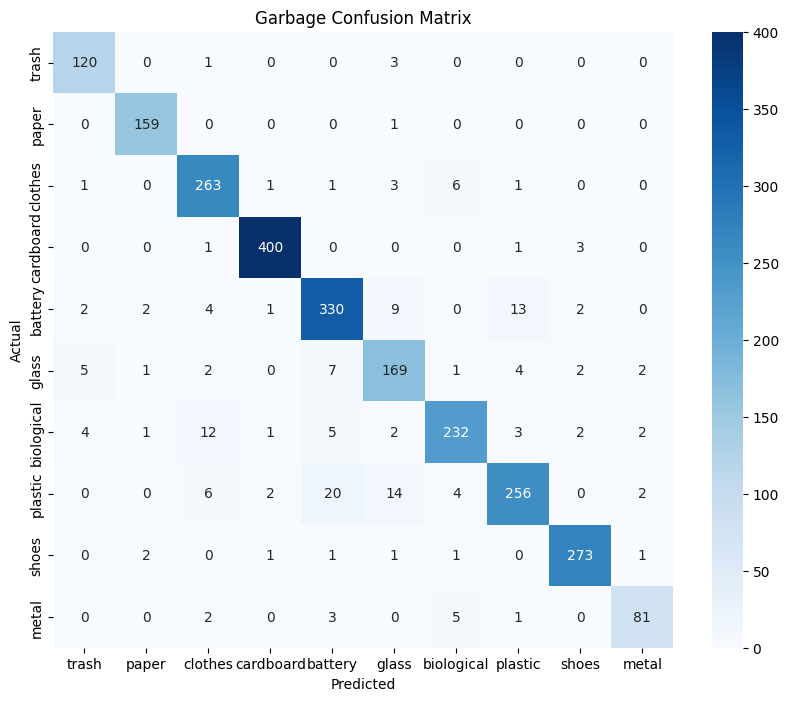

In [86]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Garbage Confusion Matrix")
plt.savefig("images/confusion_matrix.png")
plt.show()

The model excels on visually distinctive classes (clothes, shoes, biological) but confuses similar materials (glass/plastic, paper/cardboard), with trash showing the lowest performance due to its heterogeneous nature.

In [87]:
report = classification_report(y_true, y_pred, target_names=class_names)

print("Classification Report of Garbage Dataset\n")
print(report)

with open("logs/precision_finalModel.txt", "a") as f:
        f.write(report)

Classification Report of Garbage Dataset

              precision    recall  f1-score   support

       trash       0.91      0.97      0.94       124
       paper       0.96      0.99      0.98       160
     clothes       0.90      0.95      0.93       276
   cardboard       0.99      0.99      0.99       405
     battery       0.90      0.91      0.90       363
       glass       0.84      0.88      0.86       193
  biological       0.93      0.88      0.90       264
     plastic       0.92      0.84      0.88       304
       shoes       0.97      0.97      0.97       280
       metal       0.92      0.88      0.90        92

    accuracy                           0.93      2461
   macro avg       0.92      0.93      0.92      2461
weighted avg       0.93      0.93      0.93      2461



Overall test accuracy is 92% with balanced performance (macro F1: 0.92), though metal class (F1: 0.86) and similar-looking materials remain challenging.

### Save the Final Model on (.keras)

In [88]:
model_tl.save("final_model_tl.keras")

## My Garbage Image
### Predictions RGB

In [89]:
# My Photos (best 4 out of the total of photos)
my_photos = ["battery.jpeg", "cardboard.jpeg", "glass.jpeg", "plastic.jpeg"]

print(f'Analysing {len(my_photos)} of My Garbage Image...')
for img_path in my_photos:

    img = load_img(f"images/{img_path}", target_size=IMAGE_SIZE[2])
    img_array = img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)

    pred = model_tl.predict(img_array)
    pred_class = class_names[np.argmax(pred)]

    print(f"{img_path} → Predicted: {pred_class}")

Analysing 4 of My Garbage Image...
1/1 ━━━━━━━━━━━━━━━━━━━━ 11s 11s/step
battery.jpeg → Predicted: clothes
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
cardboard.jpeg → Predicted: biological
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
glass.jpeg → Predicted: biological
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
plastic.jpeg → Predicted: plastic


#### Prediction Greyscale

In [90]:
print(f'Analysing {len(my_photos)} of My Garbage Image (Grayscale)...')
for img_path in my_photos:

    img = load_img(f"images/{img_path}", target_size=IMAGE_SIZE[2])

    # Convert to grayscale then back to RGB (important for model)
    img = img.convert("L").convert("RGB")

    img_array = img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)

    pred = model_tl.predict(img_array)
    pred_class = class_names[np.argmax(pred)]

    print(f"{img_path} -> Grayscale Predicted: {pred_class}")

Analysing 4 of My Garbage Image (Grayscale)...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
battery.jpeg -> Grayscale Predicted: clothes
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
cardboard.jpeg -> Grayscale Predicted: biological
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
glass.jpeg -> Grayscale Predicted: battery
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
plastic.jpeg -> Grayscale Predicted: biological


Real-world predictions show the model performs well in controlled settings but struggles with cluttered images and similar-looking materials (e.g., battery$\to$clothes, cardboard$\to$biological), highlighting limitations of relying on visual texture alone.

### Figure 6: Real-World Image Predictions

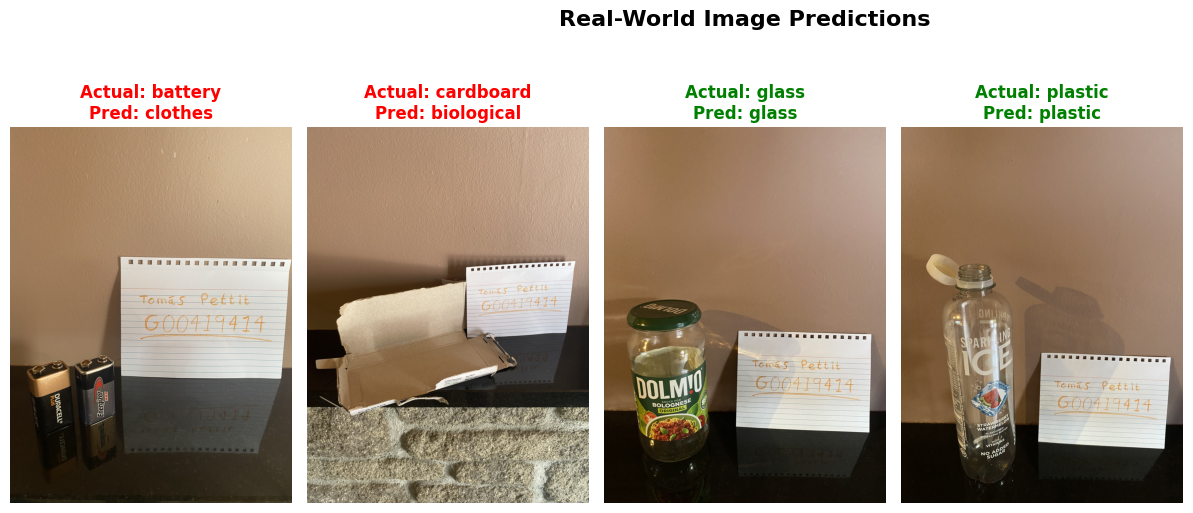

In [91]:
# ADD THIS (actual labels)
actuals_rgb = ["battery", "cardboard", "glass", "plastic"]

preds_rgb = ["clothes", "biological", "glass", "plastic" ]

plt.figure(figsize=(15, 6))

for i, (img, actual, pred) in enumerate(zip(my_photos, actuals_rgb, preds_rgb)):
    plt.subplot(1, 5, i + 1)

    image = Image.open(f"images/{img}").convert("RGB").rotate(270, expand=True)
    plt.imshow(image)

    # Green if correct, red if incorrect
    color = "green" if actual == pred else "red"

    plt.title(
        f"Actual: {actual}\nPred: {pred}",
        fontsize=12,
        color=color,
        fontweight="bold"
    )

    plt.axis("off")

plt.suptitle("Real-World Image Predictions", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.savefig("real_world_predictions_clean.png", dpi=300)
plt.show()

### Figure 7: Real-World Image Predictions (Grayscale Inputs)

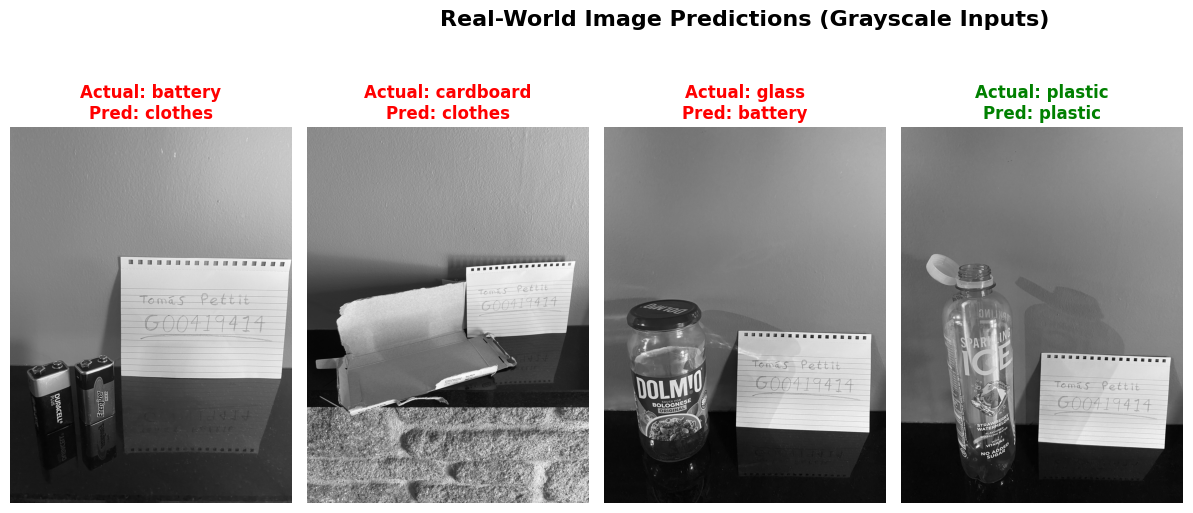

In [92]:
# Actual labels
actuals_gray = ["battery", "cardboard", "glass", "plastic"]

# Predictions from grayscale inputs
preds_gray = ["clothes", "clothes", "battery", "plastic"]

plt.figure(figsize=(15, 6))

for i, (img, actual, pred) in enumerate(zip(my_photos, actuals_gray, preds_gray)):
    plt.subplot(1, 5, i + 1)

    # Convert image to grayscale
    image = Image.open(f"images/{img}") \
                 .convert("L") \
                 .rotate(270, expand=True)

    plt.imshow(image, cmap="gray")

    # Green if correct, red if incorrect
    color = "green" if actual == pred else "red"

    plt.title(
        f"Actual: {actual}\nPred: {pred}",
        fontsize=12,
        color=color,
        fontweight="bold"
    )

    plt.axis("off")

plt.suptitle("Real-World Image Predictions (Grayscale Inputs)", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.savefig("real_world_predictions_grayscale.png", dpi=300)
plt.show()